In [5]:
import os
from langgraph.graph import START,END,StateGraph,MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.memory import BaseStore
from pydantic import BaseModel,Field
from typing import TypedDict,Annotated,List
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage
from langchain_core.runnables import RunnableConfig
from dotenv import load_dotenv
import uuid
load_dotenv()

True

In [3]:
model=ChatGroq(model="openai/gpt-oss-120b",temperature=0.2,api_key=os.getenv("GROQ_API_KEY"))

In [6]:
extractor_llm=ChatGroq(model="openai/gpt-oss-120b",temperature=0.2,api_key=os.getenv("GROQ_API_KEY"))

In [7]:
store=InMemoryStore()

In [8]:
class Memorydecision(BaseModel):
    should_write:bool=Field(description="Whether the memory should be written or not")
    memories:List[str]=Field(default_factory=list,description="The list of memories to be written")

In [9]:
memory_extractor=extractor_llm.with_structured_output(Memorydecision)

In [10]:
def rememeber_only_node(state:MessagesState,config:RunnableConfig,store:BaseStore):

    user_id=config['configurable']['user_id']

    namespace=("user",user_id,"details")

    # take latest user message
    last_msg = state["messages"][-1].content

    # LLM decides what to store
    decision: Memorydecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace, str(uuid.uuid4()), {"data":mem})

    return {"messages":[AIMessage(content="noted..")]}

In [11]:
builder=StateGraph(MessagesState)
builder.add_node("remember_only",rememeber_only_node)
builder.add_edge(START,"remember_only")
builder.add_edge("remember_only",END)
graph=builder.compile(store=store)

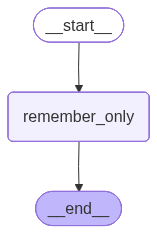

In [12]:
graph

In [18]:
config={"configurable":{"user_id":"u1"}}

result=graph.invoke({"messages":[HumanMessage(content="hi my name is rahul kapade")]},config=config)

result['messages'][-1].content

'noted..'

In [16]:
config={"configurable":{"user_id":"u1"}}

result=graph.invoke({"messages":[HumanMessage(content="i love python language ")]},config=config)

result['messages'][-1].content

'noted..'

In [19]:
items=store.search(('user',"u1","details"))

for item in items:
    print(item.value['data'])


User's name is Rahul Kapade.
User loves the Python programming language.
User loves the Python programming language.
User's name is Rahul Kapade.


# without duplication


In [20]:
store=InMemoryStore()

In [47]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [48]:

class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [59]:
memory_extractor=extractor_llm.with_structured_output(MemoryDecision)

In [60]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list."""

In [61]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1]

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}
            

In [62]:
builder=StateGraph(MessagesState)
builder.add_node("chat_node",chat_creates_memory_node)

builder.add_edge(START,"chat_node")
builder.add_edge("chat_node",END)

graph=builder.compile(store=store)

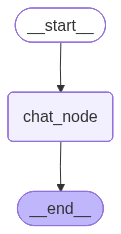

In [63]:
graph

In [64]:
config = {"configurable": {"user_id": "u1"}}

In [65]:
r1 = graph.invoke({"messages": [HumanMessage(content="hi my name is Rahul")]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [66]:
r2 = graph.invoke({"messages": [{"role": "user", "content": "I like Python for programming."}]}, config)
print("\nAssistant:", r2["messages"][-1].content)


Assistant: Noted.


In [67]:
for it in store.search(("user", "u1", "details")):
    print(it.value['data'])

User's name is Rahul.
User's name is Rahul.
User's name is Rahul.
The user prefers Python for programming.


In [68]:
config = {"configurable": {"user_id": "u2"}}

In [69]:
r1 = graph.invoke({"messages": [HumanMessage(content="hi my name is Rk")]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [70]:
r1 = graph.invoke({"messages": [HumanMessage(content="i love java")]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [71]:
r1 = graph.invoke({"messages": [HumanMessage(content="hi my name is Rk")]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [72]:
for it in store.search(("user", "u2", "details")):
    print(it.value['data'])

User's name is Rk.
User loves Java.
